# Técnicas Clásicas de Visión
| IA 5.2 Computer Vision   
| FCEIA - UNR

En este cuaderno se desarrollan ejercicios relacionados a la calse 2 "Técnicas clásicas de Visión" de la materia.

# Librerías a utilizar

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 1: Detección de bordes

La detección de bordes es una herramienta fundamental que usan internamente los modelos para poder obtener features de las imágenes / objetos a clasificar / detectar.

## Filtro sobel



> "El operador Sobel es un ejemplo clásico de un detector de características basado en la convolución. No utiliza un solo filtro, sino un par de kernels de 3×3 diseñados para trabajar en conjunto. Su propósito es calcular una aproximación del gradiente de intensidad de la imagen en cada punto. En términos sencillos, miden la tasa y la dirección del cambio de brillo. Un filtro está optimizado para detectar cambios en la dirección horizontal, mientras que el otro lo está para la dirección vertical. Juntos, proporcionan una imagen completa de la estructura de bordes de la escena." -https://datasciencepythonblog.net/los-2-filtros-de-convolucion-del-operador-sobel-tensorflow/



Kernel para resaltado Horizontal ------|-------     Kernel para resaltado Vertical
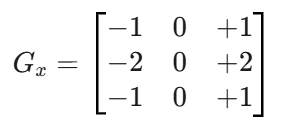 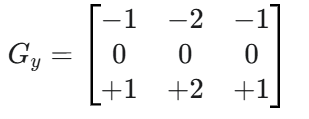

**OJO**
Resaltado horizontal significa que detecta el cambios fuertes de manera horizontal -> resalta lineas verticales.

-->|-->

-->|-->

-->|-->

Resaltado vertical significa que detecta los cambios fuertes de manera vertical -> resalta lineas horizontales

↓ - -  ↓- -   ↓

➖➖➖

↓ - -  ↓- -   ↓


Definición de kernels en python

In [ ]:
Gx = np.array([-1,0,1,
      -2,0,2,
      -1,0,1], dtype=np.float32)
Gy = np.array([-1,-2,-1,
       0,0,0,
       1,2,1], dtype=np.float32)

### Ejemplo implementación sobel

Trabajaremos con la siguiente imagen

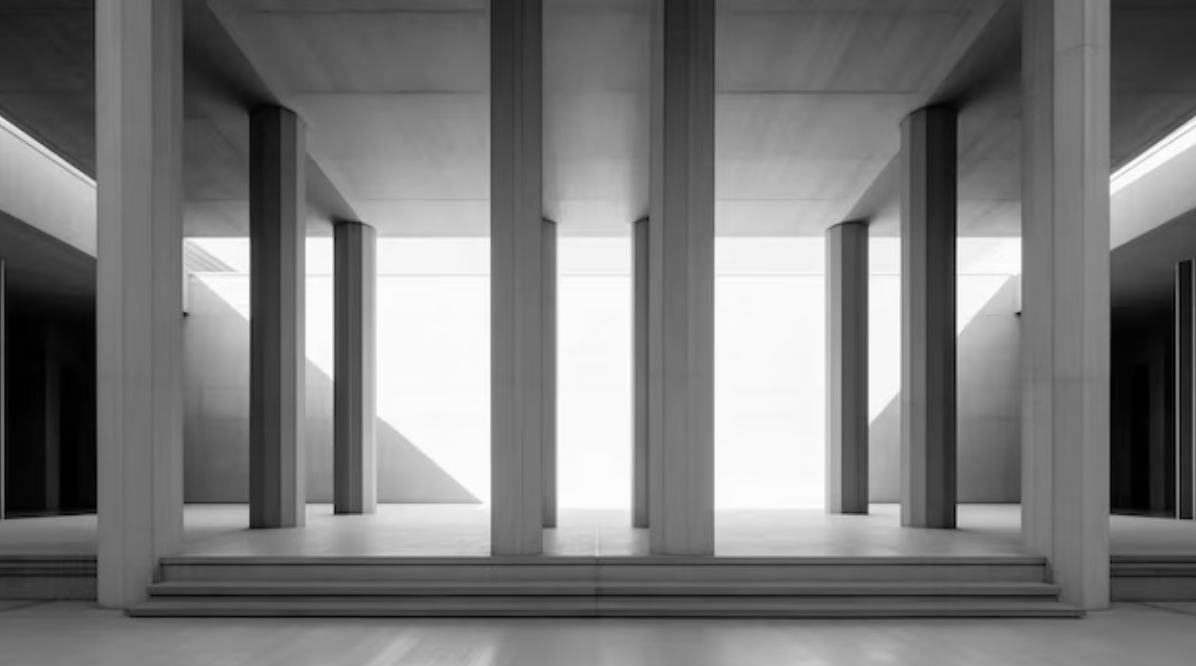

In [ ]:
img_columnas_path = '/content/columnas.png'
columnas = cv2.imread(img_columnas_path)
columnas_gray = cv2.cvtColor(columnas, cv2.COLOR_BGR2GRAY)

cv2_imshow(columnas_gray)



### Filtro Horizontal Gx

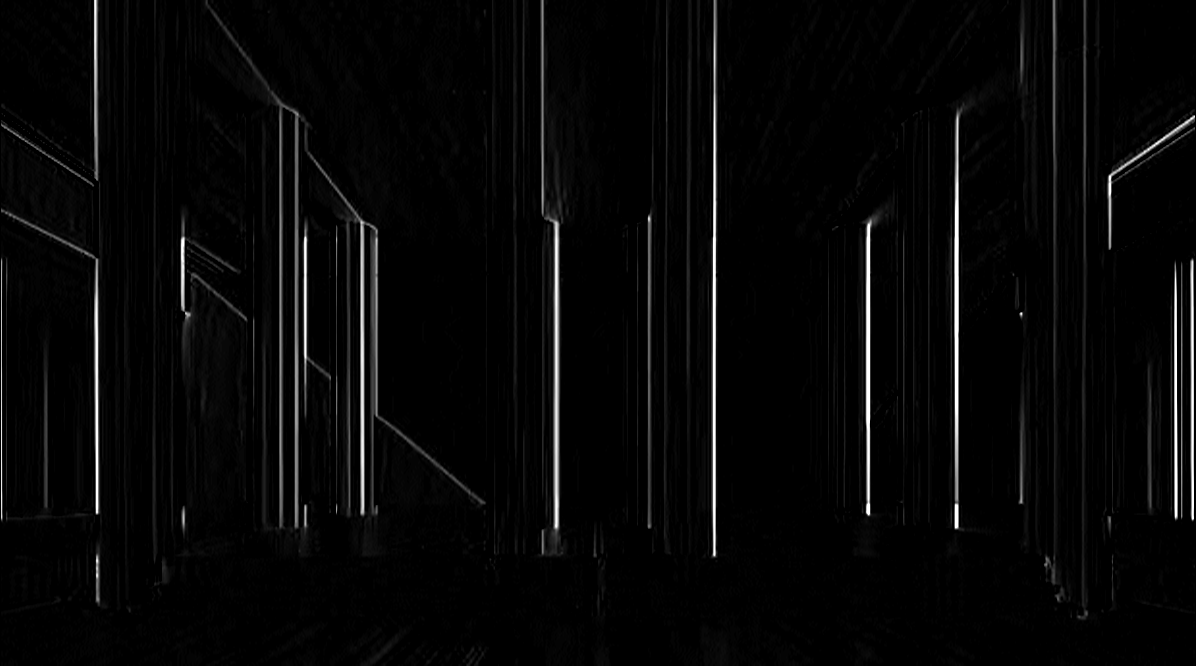

In [ ]:
# Aplicamos kernel Gx a imagen para obtener el gradiente horizontal
img_Gx = cv2.filter2D(columnas_gray, cv2.CV_32F, Gx.reshape(3,3))
cv2_imshow(img_Gx)

### Filtro vertical Gy

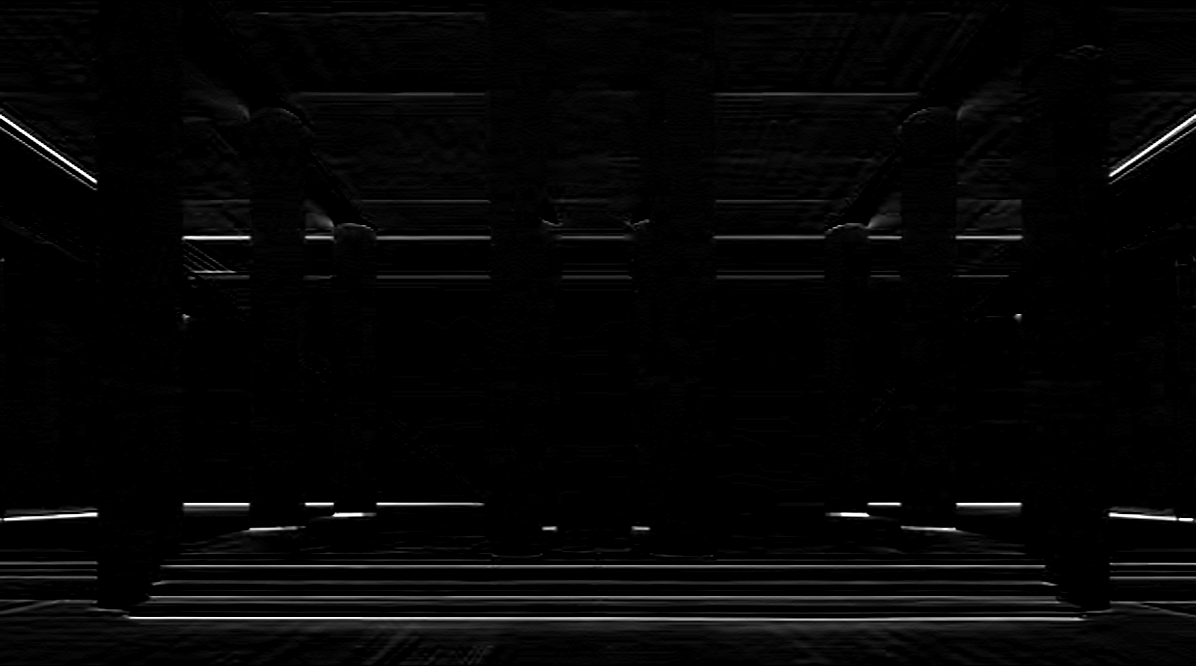

In [ ]:
# Aplicamos kernel Gy a imagen para obtener el gradiente vertical
img_Gy = cv2.filter2D(columnas_gray, cv2.CV_32F, Gy.reshape(3,3))
cv2_imshow(img_Gy)

### Calculo de magnitud del gradiente

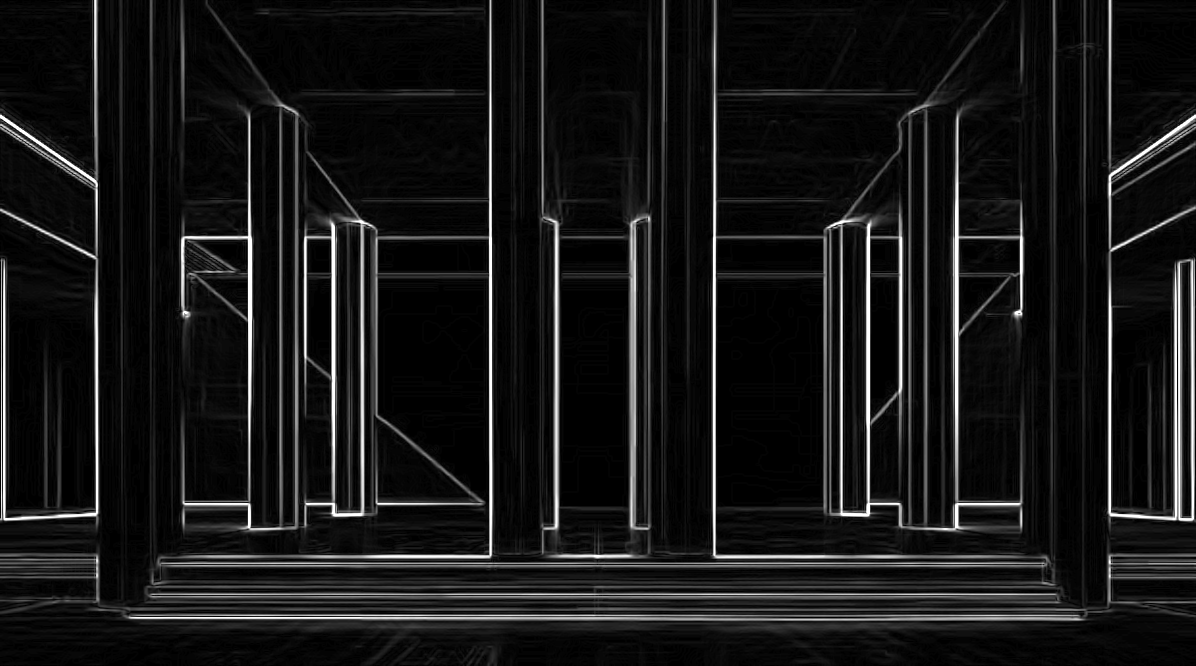

In [ ]:
img_columnas_Gx_ = img_Gx.astype(np.float32)
img_columnas_Gy_ = img_Gy.astype(np.float32)

magnitude = np.sqrt(img_columnas_Gx_**2 + img_columnas_Gy_**2)
cv2_imshow(magnitude)


Falta normalizar

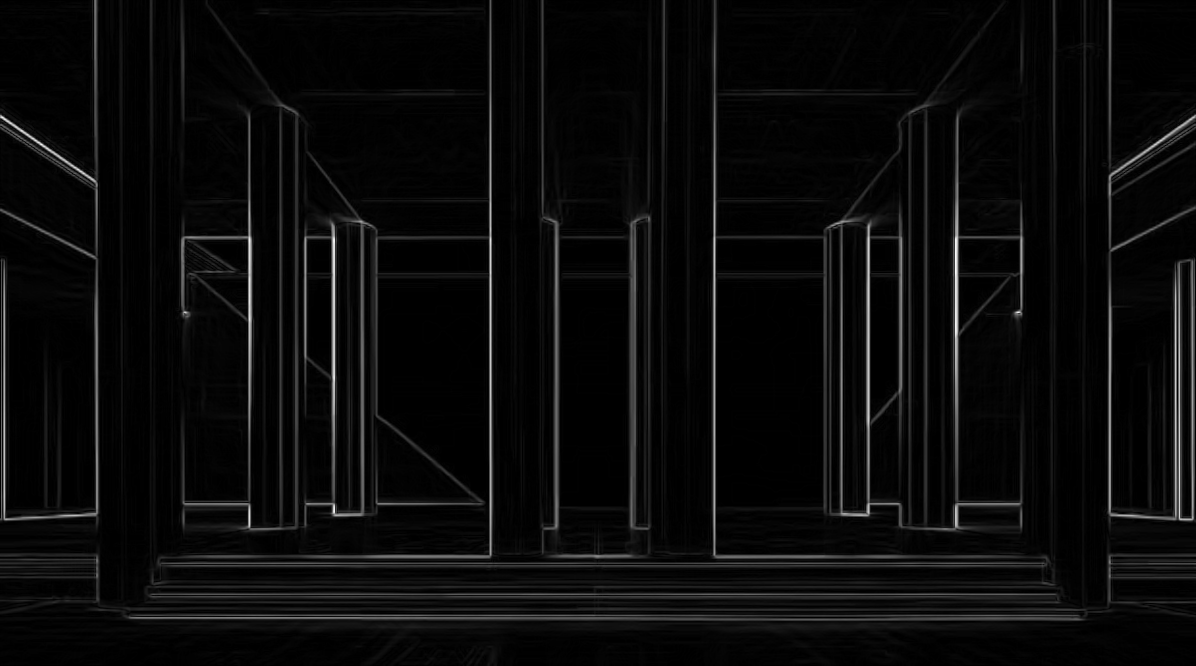

In [ ]:
magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
magnitude = magnitude.astype(np.uint8)

cv2_imshow(magnitude)




### Aplicación directa con cv2.sobel

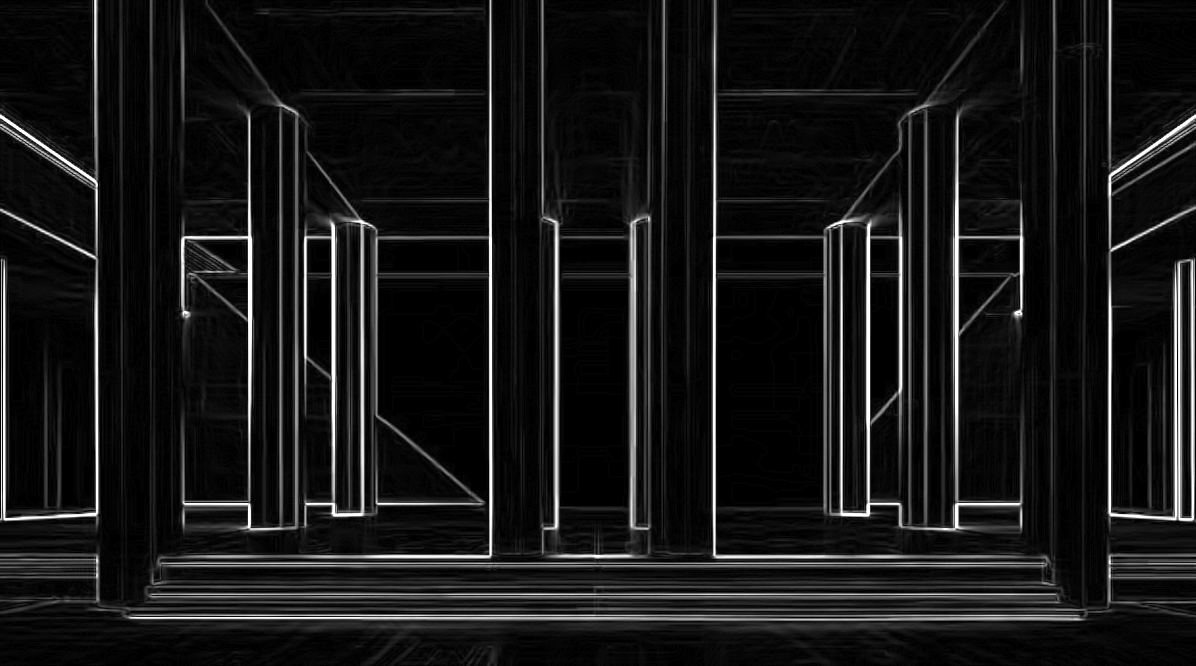

In [ ]:
sobel_x = cv2.Sobel(columnas_gray, cv2.CV_32F, 1, 0)
sobel_y = cv2.Sobel(columnas_gray, cv2.CV_32F, 0, 1)

magnitude = cv2.magnitude(sobel_x, sobel_y)
magnitude = cv2.convertScaleAbs(magnitude)

cv2_imshow(magnitude)


# Consigna sobel

Remarca los ladrillos en la siguiente foto "ladrillos.png".

Luego cuenta la cantidad de ladrillos (de manera aproximada, no es necesario que de exacto).